### Build a basic chatbot  with langgraph (Graph API)

In [54]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [55]:
class State(TypedDict):
    # Mesages have the type "list". The 'add_messages' function
    # in the annotation defined how this state key should be updated
    # (in this case, it appends the messages to the list, rather than overwriting them).
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [56]:
graph_builder

In [57]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [58]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# llm = ChatGroq(model="llamma2-8b-8192")
# llm


In [59]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DEE7C0F710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DEE7B8B7D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [60]:
## Node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [61]:
graph_builder = StateGraph(State)

## Adding nodes
graph_builder.add_node("llmchatbot", chatbot)
## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)
# graph_builder

## Compiling the graph
graph = graph_builder.compile()


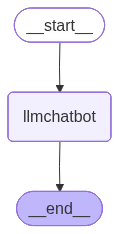

In [62]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [63]:
response = graph.invoke({"messages":"Hi there!"})


In [64]:
response["messages"]

[HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='37ca09c1-8fe8-446e-aa57-739fa7cd578c'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 38, 'total_tokens': 62, 'completion_time': 0.047036281, 'completion_tokens_details': None, 'prompt_time': 0.000952199, 'prompt_tokens_details': None, 'queue_time': 0.162440971, 'total_time': 0.04798848}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8548-a443-7263-8401-2d6477d81d17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 24, 'total_tokens': 62})]

In [65]:
for event in graph.stream({"messages":"Hi there!"}):
    # print(event)
    for value in event.values():
        print(value["messages"][-1].content)

It's nice to meet you. Is there something I can help you with or would you like to chat?


### Chatbot with tool

In [69]:
from langchain_tavily import TavilySearch

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")


tool = TavilySearch(max_results=2)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Paris',
   'title': 'Paris - Wikipedia',
   'content': "| | * v * t * e Communes in the Paris metropolitan area | | --- | | Population over 2 million | * Paris | | Population over 100,000 | * Argenteuil * Boulogne-Billancourt * Montreuil * Saint-Denis | | Population over 75,000 | * Asnières-sur-Seine * Aubervilliers * Aulnay-sous-Bois * Champigny-sur-Marne * Colombes * Courbevoie * Créteil * Nanterre * Rueil-Malmaison * Versailles * Vitry-sur-Seine | | Population over 50,000 | * Antony * Le Blanc-Mesnil * Bobigny * Bondy * Cergy * Chelles * Clamart * Clichy * Corbeil-Essonnes * Drancy * Épinay-sur-Seine * Évry-Courcouronnes * Fontenay-sous-Bois * Issy-les-Moulineaux * Ivry-sur-Seine * Levallois-Perret * Maisons-Alfort * Massy * Meaux * Neuilly-sur-Seine * Noisy-le-Grand * Pantin * Saint-Maur-des-Fossés * Saint-Ouen-sur-Seine * Sar

In [71]:
## custom function
def multiply(a:int, b:int) -> int:
    """Multiply two numbers
    Args:
        a: first number
        b: second number
    Returns:
        The product of a and b
    
    """
    return a * b


In [72]:
tools = [tool, multiply]

In [73]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DEE7C0F710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DEE7B8B7D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input

In [74]:
## Sategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    ## if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    #if the message from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", END)

## complie the graph
graph = graph_builder.compile()



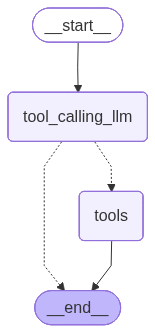

In [75]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [78]:
response = graph.invoke({"messages":"What is the recent AI news?"})


In [79]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/lanceeliot/2026/04/12/neuro-symbolic-ai-gains-needed-street-cred-after-fluky-leak-of-anthropic-claude-code-components/", "title": "Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Code Components - Forbes", "score": 0.88875884, "published_date": "Sun, 12 Apr 2026 07:15:00 GMT", "content": "# Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Code Components. # Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Code Components. In today’s column, I examine the recent inadvertent leak of various AI components that are internal to the widely popular agentic assistant app of Anthropic, Claude Code, which in turn has stoked renewed street cred for advocates of neuro-symbolic AI, though not everyone is sold on what the leaked code proves or doesn’t prove. Not to be det

In [80]:
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

What is the recent AI news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k0qh20epa)
 Call ID: k0qh20epa
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/lanceeliot/2026/04/12/neuro-symbolic-ai-gains-needed-street-cred-after-fluky-leak-of-anthropic-claude-code-components/", "title": "Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Code Components - Forbes", "score": 0.88875884, "published_date": "Sun, 12 Apr 2026 07:15:00 GMT", "content": "# Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Co

In [83]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yqvcxj7tx)
 Call ID: yqvcxj7tx
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (sc37msc4m)
 Call ID: sc37msc4m
  Args:
    a: 5
    b: 10
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/lanceeliot/2026/04/12/neuro-symbolic-ai-gains-needed-street-cred-after-fluky-leak-of-anthropic-claude-code-components/", "title": "Neuro-Symbolic AI Gains Needed Street Cred After Fluky Leak Of Anthropic Claude Code Components - Forbes", "score": 0.88875884, "published_date": "Sun, 12 Apr 2026 07:15:00 GMT", "content": "# Neuro-Symbo

## react agent architecture

In [87]:
## Sategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    ## if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    #if the message from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", "tool_calling_llm")

## complie the graph
graph = graph_builder.compile()



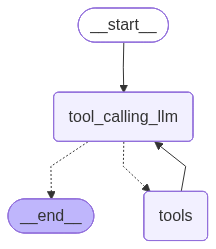

In [88]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [89]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0krynfq4m)
 Call ID: 0krynfq4m
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (czv8k0rgq)
 Call ID: czv8k0rgq
  Args:
    a: 5
    b: 10
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/04/12/at-the-humanx-conference-everyone-was-talking-about-claude/", "title": "At the HumanX conference, everyone was talking about Claude - TechCrunch", "score": 0.6216563, "published_date": "Sun, 12 Apr 2026 15:00:00 GMT", "content": "At the HumanX AI conference in San Francisco this week, thousands of techies descended upon the city

### Adding memory in Agentic Graph

In [90]:
response = graph.invoke({"messages":"Hello, my name is Arpit"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Arpit
================================== Ai Message ==================================

Hello Arpit, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [91]:
response = graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started. If you'd like to share your name, I'd be happy to chat with you.


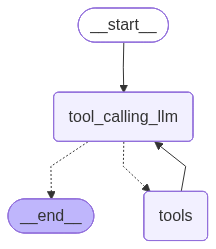

In [96]:
## Sategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    ## if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    #if the message from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", "tool_calling_llm")

## complie the graph
graph = graph_builder.compile(checkpointer=memory)


## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [97]:
config={"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hello, my name is Arpit"}, config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Arpit', additional_kwargs={}, response_metadata={}, id='12b5f12a-3bd0-4834-98da-eb4649c47174'),
  AIMessage(content="Hello Arpit, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1790, 'total_tokens': 1817, 'completion_time': 0.067794374, 'completion_tokens_details': None, 'prompt_time': 0.135012607, 'prompt_tokens_details': None, 'queue_time': 0.160080173, 'total_time': 0.202806981}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8aab-a366-7962-92c4-7f79862a91c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1790, 'output_tokens': 27, 'total_tokens': 1817})]}

In [98]:
response["messages"][-1].content

"Hello Arpit, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [100]:
response = graph.invoke({"messages":"Hey, What is my name?"}, config=config)
response["messages"][-1].content

'Your name is Arpit.'

In [101]:
response = graph.invoke({"messages":"Do you remember my name"}, config=config)
response["messages"][-1].content

"Yes, I remember your name, it's Arpit."

### Streaming

In [102]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [104]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

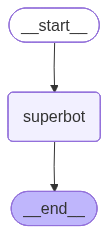

In [106]:
graph = StateGraph(State)

## node
graph.add_node("superbot", superbot)
##edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)


## complie the graph
graph_builder = graph.compile(checkpointer=memory)


# Display
from IPython.display import Image, display

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


In [107]:
#invocation
config = {"configurable":{"thread_id":"1"}}

response = graph_builder.invoke({"messages":"Hi there"}, config=config)

for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

Hi there
None
================================== Ai Message ==================================

It's nice to meet you. Is there something I can help you with or would you like to chat?
None


#### Methods - .stream() and astream()

In LangGraph, .stream() and .astream() are methods used to yield real-time updates as a graph executes, rather than waiting for the entire process to finish

.stream() is synchronous and returns a standard Python iterator. .astream() is asynchronous and returns an AsyncIterator, requiring the async for syntax.


##### Additional parameters - 
- values: Emits the full state of the graph after every step.
- updates: Emits only the specific changes made to the state by the most recent node.

In [108]:
#invocation
config = {"configurable":{"thread_id":"1"}}
for chunk in graph_builder.stream({"messages":"Hi, my name is Arpit and I like playing cricket"}, config=config, stream_mode="updates"):
    print(chunk)

# for m in response["messages"]:
#     print(m.pretty_print())

{'superbot': {'messages': [AIMessage(content='Nice to meet you, Arpit. Cricket is a fantastic sport. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching it more?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 81, 'total_tokens': 121, 'completion_time': 0.109915424, 'completion_tokens_details': None, 'prompt_time': 0.007639111, 'prompt_tokens_details': None, 'queue_time': 0.162028956, 'total_time': 0.117554535}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fdb-ee95-7633-92c5-fed8865e2746-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 81, 'output_tokens': 40, 'total_tokens': 121})]}}


In [109]:
config = {"configurable":{"thread_id":"1"}}
for chunk in graph_builder.stream({"messages":"Hi, my name is Arpit and I like playing cricket"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi there', additional_kwargs={}, response_metadata={}, id='a743242f-9b58-4b57-b0c5-1e5c7d578d92'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 37, 'total_tokens': 60, 'completion_time': 0.04525613, 'completion_tokens_details': None, 'prompt_time': 0.001973747, 'prompt_tokens_details': None, 'queue_time': 0.16052665, 'total_time': 0.047229877}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9f29-3e83-7de0-b40a-e45b65298987-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 23, 'total_tokens': 60}), HumanMessage(content='Hi, my name is Arpit and I like playing cricket', additional_kwargs={}, response_m

In [111]:
config = {"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"Hi, my name is Arpit and I like playing cricket"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hi Arpit, nice to meet you. It's fantastic that you enjoy playing cricket. What's your favorite position to play - batsman, bowler, or wicket-keeper? Do you play in a local team or just for fun with friends?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 126, 'total_tokens': 179, 'completion_time': 0.159115366, 'completion_tokens_details': None, 'prompt_time': 0.007626167, 'prompt_tokens_details': None, 'queue_time': 0.055753852, 'total_time': 0.166741533}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fdd-fa38-79a3-8ed9-ade2eab16849-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 126, 'output_tokens': 53, 'total_tokens': 179})]}}


In [112]:
# config = {"configurable":{"thread_id":"1"}}
for chunk in graph_builder.stream({"messages":"Hi, I also like football"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Arpit and I like playing cricket', additional_kwargs={}, response_metadata={}, id='0b2ed287-7054-410f-90e3-bdb3aa1db228'), AIMessage(content="Hi Arpit, nice to meet you. Cricket is an exciting sport, and it's great that you enjoy playing it. Are you a fan of any particular team or player? Do you have a favorite cricket format, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 47, 'total_tokens': 105, 'completion_time': 0.158256483, 'completion_tokens_details': None, 'prompt_time': 0.006400037, 'prompt_tokens_details': None, 'queue_time': 0.077361955, 'total_time': 0.16465652}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9fdd-dd85-7a33-a247-3d606a5be990-0', tool_calls=[], invalid_tool_calls=[], usage_m

In [115]:
config = {"configurable":{"thread_id":"5"}}
async for chunk in graph_builder.astream_events({"messages":"Hi, I also like football"}, config=config, version="v1"):
    print(chunk)

{'event': 'on_chain_start', 'run_id': '019d9fe1-8c63-7f31-9935-248417b728d2', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '5'}, 'data': {'input': {'messages': 'Hi, I also like football'}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'superbot', 'run_id': '019d9fe1-8cb2-7061-a949-f479da1a76fe', 'tags': ['graph:step:1'], 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:a60443ab-9865-6717-eb76-4e2495a83494'}, 'data': {'input': {'messages': [HumanMessage(content='Hi, I also like football', additional_kwargs={}, response_metadata={}, id='4f4ec1ae-fe8b-4c9f-92e4-3087a810f006')]}}, 'parent_ids': []}
{'event': 'on_chat_model_start', 'name': 'ChatGroq', 'run_id': '019d9fe1-8cc9-7be3-b7a1-7ca7f3c0c78d', 'tags': ['seq:step:1'], 'metadata': {'thread_id': '5', 'ls_integration': 'l